In [1]:

# Cell 0 — Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

PROCESSED = Path('../data/processed')
FIGDIR = Path('../reports/figures')
FIGDIR.mkdir(parents=True, exist_ok=True)

In [2]:

# Cell 1 — Load preprocessed artifacts from Notebook 2
X_cat = pd.read_csv(PROCESSED / 'X_cat.csv')
context = pd.read_csv(PROCESSED / 'context.csv')
inventory = pd.read_csv(PROCESSED / 'column_inventory.csv')
mapping = pd.read_csv(PROCESSED / 'question_mapping.csv')

print("X_cat shape :", X_cat.shape)      # expect (1146, 36)
print("context shape:", context.shape)   # expect (1146, 6)
print("\nX_cat dtypes:")
print(X_cat.dtypes.value_counts())
print("\ncontext columns:", context.columns.tolist())

X_cat shape : (1146, 36)
context shape: (1146, 6)

X_cat dtypes:
int64    36
Name: count, dtype: int64

context columns: ['q56', 'q57', 'q58', 'q62', 'q63', 'q25']


In [3]:

# Cell 2 — Sanity checks
print("=== X_cat ===")
assert X_cat.shape == (1146, 36), f"Unexpected shape: {X_cat.shape}"
assert X_cat.isna().sum().sum() == 0, "X_cat still contains NaNs"

# Safer check that works across pandas versions
non_numeric = X_cat.select_dtypes(exclude=['number']).columns.tolist()
assert len(non_numeric) == 0, f"X_cat still has non-numeric columns: {non_numeric}"
print("✓ X_cat is clean (no NaNs, all numeric)")

print("\nValue ranges (should be mostly -1 … 4):")
print(X_cat.describe().loc[['min', 'max']].T.sort_values('max'))

print("\n=== context ===")
print("Missing values:\n", context.isna().sum())
print("\nDtypes:\n", context.dtypes)

=== X_cat ===
✓ X_cat is clean (no NaNs, all numeric)

Value ranges (should be mostly -1 … 4):
     min  max
q53  0.0  1.0
q51  0.0  1.0
q05 -1.0  2.0
q06 -1.0  2.0
q09  0.0  2.0
q11  0.0  2.0
q07  0.0  2.0
q08  0.0  2.0
q29 -1.0  2.0
q14  0.0  2.0
q15  0.0  2.0
q27 -1.0  2.0
q36 -1.0  2.0
q37  0.0  2.0
q12  0.0  2.0
q13  0.0  2.0
q47  0.0  2.0
q48  0.0  2.0
q45 -1.0  2.0
q41  0.0  2.0
q39  0.0  2.0
q46  0.0  2.0
q42  0.0  2.0
q32 -1.0  2.0
q33 -1.0  2.0
q30 -1.0  3.0
q35 -1.0  3.0
q31 -1.0  3.0
q44  0.0  3.0
q34 -1.0  3.0
q26 -1.0  3.0
q28 -1.0  3.0
q54 -1.0  3.0
q55 -1.0  3.0
q43 -1.0  4.0
q10 -1.0  4.0

=== context ===
Missing values:
 q56    0
q57    0
q58    0
q62    0
q63    0
q25    0
dtype: int64

Dtypes:
 q56    float64
q57        str
q58        str
q62        str
q63        str
q25      int64
dtype: object


In [4]:

# Cell 3 — What is inside X_cat?
print("Columns in X_cat:")
print(sorted(X_cat.columns.tolist()))

print("\nRole distribution from inventory (for reference):")
print(inventory['role'].value_counts())

Columns in X_cat:
['q05', 'q06', 'q07', 'q08', 'q09', 'q10', 'q11', 'q12', 'q13', 'q14', 'q15', 'q26', 'q27', 'q28', 'q29', 'q30', 'q31', 'q32', 'q33', 'q34', 'q35', 'q36', 'q37', 'q39', 'q41', 'q42', 'q43', 'q44', 'q45', 'q46', 'q47', 'q48', 'q51', 'q53', 'q54', 'q55']

Role distribution from inventory (for reference):
role
clustering_candidate      36
identifier_or_freetext    10
sparse_subgroup            8
context                    7
near_constant              2
Name: count, dtype: int64


In [5]:
# Cell 3b —  Remove entire previous-employer block (Block D)
# Reason: These variables describe past workplaces and the structural
# "-1 = Not applicable" coding caused an earlier clustering attempt
# (pre-revision) to produce a clu
# ster almost purely defined by
# "no previous employers". We remove them here to build a cleaner
# attitudinal clustering solution based only on the current workplace.

block_d_cols = inventory.loc[
    inventory['block'] == 'D_previous_employer', 'short_id'
].tolist()

# Keep only columns that actually exist in X_cat
block_d_in_xcat = [c for c in block_d_cols if c in X_cat.columns]

print("Block D columns that will be removed:")
print(sorted(block_d_in_xcat))
print(f"\nX_cat shape before removal: {X_cat.shape}")

X_cat = X_cat.drop(columns=block_d_in_xcat)

print(f"X_cat shape after removal:  {X_cat.shape}")
print(f"Remaining columns ({X_cat.shape[1]}):")
print(sorted(X_cat.columns.tolist()))

# Sanity check: report states the revised feature set has 25 variables
assert X_cat.shape[1] == 25, (
    f"Expected 25 columns after Block D removal, got {X_cat.shape[1]}. "
    "Check block_d_cols / block_d_in_xcat against the report's stated column count."
)
print("✓ Column count matches report (25 variables)")

Block D columns that will be removed:
['q26', 'q27', 'q28', 'q29', 'q30', 'q31', 'q32', 'q33', 'q34', 'q35', 'q36']

X_cat shape before removal: (1146, 36)
X_cat shape after removal:  (1146, 25)
Remaining columns (25):
['q05', 'q06', 'q07', 'q08', 'q09', 'q10', 'q11', 'q12', 'q13', 'q14', 'q15', 'q37', 'q39', 'q41', 'q42', 'q43', 'q44', 'q45', 'q46', 'q47', 'q48', 'q51', 'q53', 'q54', 'q55']
✓ Column count matches report (25 variables)


In [6]:

# Cell 3c — Mode-impute q45's residual non-structural missingness
#
# q44 = 0 → q45 = -1 in 100% of cases: this is the genuine structural
# routing gate and is left untouched.
#
# q44 = 1, 2, 3 → q45 = -1 in 20.9% / 6.2% / 16.7% of cases: this is
# residual item non-response, not a structural gap (same category as
# Bug 3's q06/q44 treatment in Notebook 2 — non-response is imputed,
# not coded -1). We mode-impute these within each q44 subgroup.

print("Before fix — q45 = -1 counts by q44:")
print(X_cat.groupby('q44')['q45'].apply(lambda s: (s == -1).sum()))

for q44_val in [1, 2, 3]:
    mask_group = X_cat['q44'] == q44_val
    mask_missing = mask_group & (X_cat['q45'] == -1)
    mask_valid = mask_group & (X_cat['q45'] != -1)

    if mask_missing.sum() == 0:
        continue

    mode_val = X_cat.loc[mask_valid, 'q45'].mode()[0]
    X_cat.loc[mask_missing, 'q45'] = mode_val

    print(f"q44={q44_val}: imputed {mask_missing.sum()} rows with mode={mode_val}")

print("\nAfter fix — q45 = -1 counts by q44:")
print(X_cat.groupby('q44')['q45'].apply(lambda s: (s == -1).sum()))

assert (X_cat.loc[X_cat['q44'] != 0, 'q45'] == -1).sum() == 0, \
    "Residual q45 missingness remains outside the q44=0 structural gate"
print("\n✓ q45 residual non-response resolved; structural gate (q44=0) unchanged")

Before fix — q45 = -1 counts by q44:
q44
0    543
1     58
2     12
3     22
Name: q45, dtype: int64
q44=1: imputed 58 rows with mode=0
q44=2: imputed 12 rows with mode=2
q44=3: imputed 22 rows with mode=2

After fix — q45 = -1 counts by q44:
q44
0    543
1      0
2      0
3      0
Name: q45, dtype: int64

✓ q45 residual non-response resolved; structural gate (q44=0) unchanged


In [7]:

# Cell 4 — Standardise X_cat before PCA
# PCA is scale-sensitive. Even though the ordinal codes are already
# numeric, columns have different ranges (-1…1 vs -1…4), so we
# standardise to mean 0 / sd 1.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cat)

print("X_scaled shape:", X_scaled.shape)
print("Column means (should be ~0):", np.round(X_scaled.mean(axis=0)[:5], 4))
print("Column stds  (should be ~1):", np.round(X_scaled.std(axis=0)[:5], 4))

X_scaled shape: (1146, 25)
Column means (should be ~0): [-0.  0.  0.  0. -0.]
Column stds  (should be ~1): [1. 1. 1. 1. 1.]


In [8]:

# Cell 5 — Fit PCA
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
X_pca_full = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained variance by component (first 15):")
for i, (ev, cum) in enumerate(zip(explained[:15], cumulative[:15]), 1):
    print(f"  PC{i:2d}: {ev*100:5.2f}%   cumulative: {cum*100:5.2f}%")

Explained variance by component (first 15):
  PC 1: 21.83%   cumulative: 21.83%
  PC 2: 17.07%   cumulative: 38.90%
  PC 3:  7.71%   cumulative: 46.61%
  PC 4:  6.12%   cumulative: 52.73%
  PC 5:  5.00%   cumulative: 57.73%
  PC 6:  4.19%   cumulative: 61.92%
  PC 7:  3.70%   cumulative: 65.62%
  PC 8:  3.38%   cumulative: 69.00%
  PC 9:  3.29%   cumulative: 72.29%
  PC10:  2.98%   cumulative: 75.26%
  PC11:  2.85%   cumulative: 78.11%
  PC12:  2.74%   cumulative: 80.85%
  PC13:  2.54%   cumulative: 83.39%
  PC14:  2.12%   cumulative: 85.51%
  PC15:  1.98%   cumulative: 87.49%


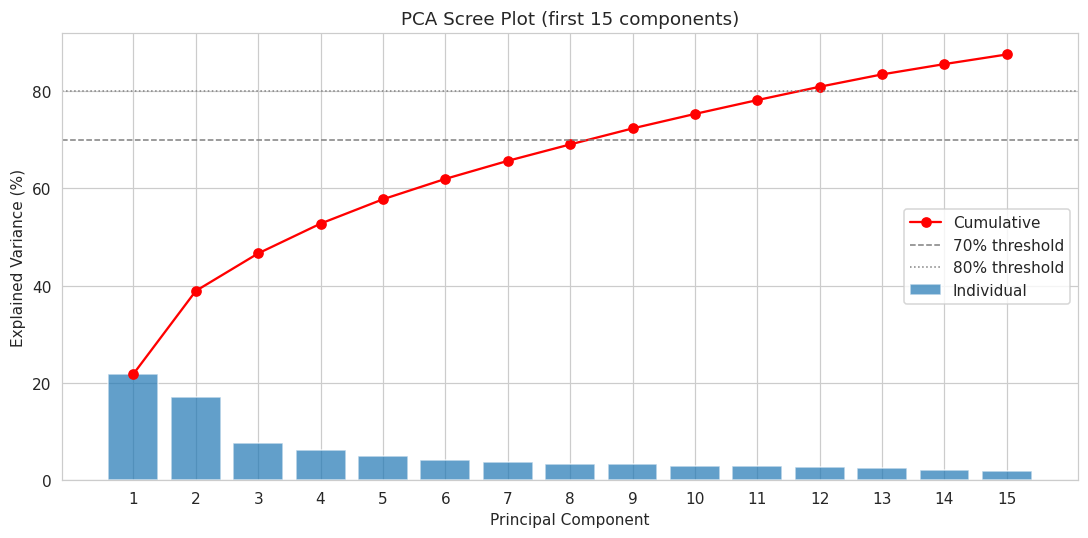

In [9]:

# Cell 6 — Scree plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(range(1, 16), explained[:15] * 100, alpha=0.7, label='Individual')
ax.plot(range(1, 16), cumulative[:15] * 100, 'o-', color='red', label='Cumulative')
ax.axhline(70, color='gray', linestyle='--', linewidth=1, label='70% threshold')
ax.axhline(80, color='gray', linestyle=':', linewidth=1, label='80% threshold')

ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA Scree Plot (first 15 components)')
ax.set_xticks(range(1, 16))
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / 'pca_scree.png', bbox_inches='tight')
plt.show()

In [10]:

# Cell 7 — Evaluate candidate PCA dimensionalities
#
# The scree plot provides the overall variance-retention pattern.
# Here we compare candidate component counts explicitly.
#
# The final component count will be selected using:
#   1. cumulative explained variance, and
#   2. downstream clustering validation/stability.
#
# This avoids choosing the component count from explained variance alone.

candidate_components = [8, 9, 10, 11, 12]

component_selection = []

for k in candidate_components:
    pca_k = PCA(n_components=k, random_state=42)
    pca_k.fit(X_scaled)

    cumulative_k = pca_k.explained_variance_ratio_.sum()

    component_selection.append({
        'Components': k,
        'Cumulative variance (%)': cumulative_k * 100
    })

component_selection_df = pd.DataFrame(component_selection)

print("Candidate PCA dimensionalities:")
display(component_selection_df.round(2))

Candidate PCA dimensionalities:


,Components,Cumulative variance (%)
0,8,69.00
1,9,72.29
2,10,75.26
3,11,78.11
4,12,80.85


In [11]:

# Cell 8 — Inspect PCA loadings

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_cat.columns,
    columns=[f'PC{i+1}' for i in range(len(explained))]
)

print("Top 5 absolute loadings for PC1–PC12:\n")

for pc in loadings.columns[:12]:
    top = loadings[pc].abs().sort_values(ascending=False).head(5)

    print(f"{pc}:")

    for var, val in top.items():
        sign = '+' if loadings.loc[var, pc] > 0 else '-'
        print(f"  {sign}{var}: {abs(loadings.loc[var, pc]):.3f}")

    print()

Top 5 absolute loadings for PC1–PC12:

PC1:
  +q55: 0.330
  +q47: 0.322
  +q51: 0.315
  +q53: 0.307
  +q48: 0.307

PC2:
  +q14: 0.309
  +q13: 0.295
  -q11: 0.286
  -q41: 0.268
  -q42: 0.261

PC3:
  +q08: 0.468
  +q05: 0.445
  +q06: 0.360
  +q07: 0.348
  +q09: 0.308

PC4:
  +q44: 0.606
  +q45: 0.565
  +q39: 0.282
  +q37: 0.252
  +q13: 0.189

PC5:
  +q37: 0.518
  +q39: 0.416
  +q06: 0.391
  +q05: 0.339
  -q15: 0.299

PC6:
  +q07: 0.429
  +q37: 0.376
  -q05: 0.311
  +q39: 0.302
  +q08: 0.301

PC7:
  +q12: 0.570
  +q13: 0.390
  +q10: 0.342
  +q43: 0.339
  -q37: 0.245

PC8:
  +q43: 0.563
  +q41: 0.424
  +q42: 0.392
  -q09: 0.389
  -q10: 0.178

PC9:
  +q10: 0.590
  +q46: 0.517
  -q09: 0.290
  -q12: 0.287
  +q07: 0.234

PC10:
  +q09: 0.609
  +q10: 0.457
  +q41: 0.303
  -q12: 0.291
  +q42: 0.217

PC11:
  +q43: 0.407
  -q46: 0.382
  -q12: 0.370
  -q15: 0.351
  -q14: 0.321

PC12:
  +q46: 0.626
  +q09: 0.471
  +q43: 0.316
  -q10: 0.293
  -q54: 0.209



In [12]:
# ============================================================
# Cell 8b — Commit to a final component count and build the
# actual reduced matrix. 

N_COMPONENTS_FINAL = 9

pca_final = PCA(n_components=N_COMPONENTS_FINAL, random_state=42)
X_pca_reduced = pca_final.fit_transform(X_scaled)

X_pca_df = pd.DataFrame(
    X_pca_reduced,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS_FINAL)]
)

print(f"Final X_pca_df shape: {X_pca_df.shape}")
print(f"Cumulative variance retained: {pca_final.explained_variance_ratio_.sum()*100:.2f}%")

Final X_pca_df shape: (1146, 9)
Cumulative variance retained: 72.29%


In [13]:

# Cell 8c — Component-count evidence
#
# Compare cumulative explained variance across a wider range of
# component counts. This provides explicit evidence for the chosen
# dimensionality rather than relying only on the scree plot.

component_counts = range(1, X_scaled.shape[1] + 1)

component_evidence = pd.DataFrame({
    'Components': list(component_counts),
    'Explained variance (%)': explained * 100,
    'Cumulative variance (%)': cumulative * 100
})

print("PCA component-count evidence:")
display(
    component_evidence[
        component_evidence['Components'].isin(candidate_components)
    ].round(2)
)

# Show the selected 9-component result explicitly
nine_row = component_evidence[
    component_evidence['Components'] == N_COMPONENTS_FINAL
]

print("\nSelected solution:")
display(nine_row.round(2))

# Show the first component count reaching 80% variance
reaching_80 = component_evidence[
    component_evidence['Cumulative variance (%)'] >= 80
]

if len(reaching_80) > 0:
    first_80 = reaching_80.iloc[0]

    print(
        f"\nFirst solution reaching 80% cumulative variance: "
        f"{int(first_80['Components'])} components "
        f"({first_80['Cumulative variance (%)']:.2f}%)"
    )
else:
    print("\nNo component count reaches 80% cumulative variance.")

PCA component-count evidence:


,Components,Explained variance (%),Cumulative variance (%)
7,8,3.38,69.00
8,9,3.29,72.29
9,10,2.98,75.26
10,11,2.85,78.11
11,12,2.74,80.85



Selected solution:


,Components,Explained variance (%),Cumulative variance (%)
8,9,3.29,72.29



First solution reaching 80% cumulative variance: 12 components (80.85%)


In [14]:

# Cell 8d — Check for NA / routing artefacts in current-employer variables
#
# Purpose:
# Determine whether current-employer variables show structural
# non-applicability patterns similar to the previous-employer block.
#
# Important:
# X_cat has already been cleaned to remove NaNs, so this check uses
# the original column inventory/context information where possible.
# We therefore inspect the variables identified as current-employer
# questions and look for systematic -1 / missing patterns.

print("=== Current-employer routing / NA-artifact check ===")

# Identify current-employer variables from the inventory.
current_employer_rows = inventory[
    inventory['block'].astype(str).str.contains(
        'current', case=False, na=False
    )
].copy()

print(
    f"Current-employer variables identified from inventory: "
    f"{len(current_employer_rows)}"
)

if len(current_employer_rows) > 0:
    display(
        current_employer_rows[
            [c for c in ['short_id', 'block', 'role']
             if c in current_employer_rows.columns]
        ].head(50)
    )

    current_cols = [
        c for c in current_employer_rows['short_id'].tolist()
        if c in X_cat.columns
    ]

    print(f"\nCurrent-employer variables present in X_cat: {len(current_cols)}")

    # Check the frequency of -1 for each current-employer variable.
    minus_one_summary = pd.DataFrame({
        'Variable': current_cols,
        '-1 count': [
            (X_cat[c] == -1).sum()
            for c in current_cols
        ],
        '-1 (%)': [
            (X_cat[c] == -1).mean() * 100
            for c in current_cols
        ]
    })

    minus_one_summary = minus_one_summary.sort_values(
        '-1 (%)',
        ascending=False
    )

    print("\nCurrent-employer variables with -1 / Not-applicable coding:")
    display(minus_one_summary.round(2))

else:
    print(
        "\nNo inventory block containing 'current' was identified. "
        "Inspect inventory['block'].unique() before drawing conclusions."
    )

=== Current-employer routing / NA-artifact check ===
Current-employer variables identified from inventory: 12


,short_id,block,role
4,q05,B_current_employer,clustering_candidate
5,q06,B_current_employer,clustering_candidate
6,q07,B_current_employer,clustering_candidate
7,q08,B_current_employer,clustering_candidate
8,q09,B_current_employer,clustering_candidate
9,q10,B_current_employer,clustering_candidate
10,q11,B_current_employer,clustering_candidate
11,q12,B_current_employer,clustering_candidate
12,q13,B_current_employer,clustering_candidate
13,q14,B_current_employer,clustering_candidate



Current-employer variables present in X_cat: 11

Current-employer variables with -1 / Not-applicable coding:


,Variable,-1 count,-1 (%)
5,q10,150,13.09
1,q06,127,11.08
0,q05,83,7.24
2,q07,0,0.00
3,q08,0,0.00
4,q09,0,0.00
6,q11,0,0.00
7,q12,0,0.00
8,q13,0,0.00
9,q14,0,0.00


In [15]:

# Cell 8e — Reproduce the original 36-feature PCA run
#
# Purpose:
# Reproduce the earlier PCA result reported in the case study
# before the previous-employer block was removed.
#
# This is kept separate from the final 25-feature PCA analysis.

# Reload the original 36-feature matrix from Notebook 2 output.
X_cat_original = pd.read_csv(PROCESSED / 'X_cat.csv')

print("Original feature matrix shape:", X_cat_original.shape)

assert X_cat_original.shape == (1146, 36), (
    f"Expected original X_cat to have shape (1146, 36), "
    f"but got {X_cat_original.shape}"
)

assert X_cat_original.isna().sum().sum() == 0, (
    "Original X_cat contains NaN values."
)

non_numeric_original = X_cat_original.select_dtypes(
    exclude=['number']
).columns.tolist()

assert len(non_numeric_original) == 0, (
    f"Original X_cat contains non-numeric columns: "
    f"{non_numeric_original}"
)

# Standardise the ORIGINAL 36-feature matrix.
scaler_original = StandardScaler()
X_original_scaled = scaler_original.fit_transform(X_cat_original)

# Fit PCA using all 36 components.
pca_original = PCA(random_state=42)
X_original_pca = pca_original.fit_transform(X_original_scaled)

original_explained = pca_original.explained_variance_ratio_
original_cumulative = np.cumsum(original_explained)

# Display the first 15 components.
original_pca_evidence = pd.DataFrame({
    'Component': np.arange(1, len(original_explained) + 1),
    'Explained variance (%)': original_explained * 100,
    'Cumulative variance (%)': original_cumulative * 100
})

print("\nOriginal 36-feature PCA:")
display(original_pca_evidence.head(15).round(2))

# Explicitly report the 11-component result.
pc11 = original_pca_evidence[
    original_pca_evidence['Component'] == 11
].iloc[0]

print(
    f"\n11-component solution:"
    f"\n  Individual PC11 variance: "
    f"{pc11['Explained variance (%)']:.2f}%"
    f"\n  Cumulative variance: "
    f"{pc11['Cumulative variance (%)']:.2f}%"
)

# Save the reproducibility evidence.
original_pca_evidence.to_csv(
    PROCESSED / 'original_36_feature_pca_evidence.csv',
    index=False
)

print(
    "\nSaved: "
    "data/processed/original_36_feature_pca_evidence.csv"
)

Original feature matrix shape: (1146, 36)

Original 36-feature PCA:


,Component,Explained variance (%),Cumulative variance (%)
0,1,18.36,18.36
1,2,15.03,33.40
2,3,10.60,44.00
3,4,5.58,49.57
4,5,4.86,54.44
5,6,3.66,58.09
6,7,2.96,61.05
7,8,2.81,63.87
8,9,2.61,66.48
9,10,2.49,68.97



11-component solution:
  Individual PC11 variance: 2.36%
  Cumulative variance: 71.33%

Saved: data/processed/original_36_feature_pca_evidence.csv


In [16]:
# Cell 8f — check whether q45's -1/missing pattern is routed by q44
ct = pd.crosstab(X_cat['q44'], X_cat['q45'] == -1)
print(ct)
print("\nq45 = -1 rate by q44 answer:")
print((X_cat.groupby('q44')['q45'].apply(lambda s: (s == -1).mean() * 100)).round(1))

# does this pair distort the PCA the same way Block D did?
na_q45 = (X_cat['q45'] == -1).astype(int)
print("\nCorrelation of each PC with q45's NA flag:")
print(pd.Series({c: np.corrcoef(X_pca_df[c], na_q45)[0,1] for c in X_pca_df.columns}).round(2))

q45  False  True 
q44              
0        0    543
1      278      0
2      193      0
3      132      0

q45 = -1 rate by q44 answer:
q44
0    100.0
1      0.0
2      0.0
3      0.0
Name: q45, dtype: float64

Correlation of each PC with q45's NA flag:
PC1   -0.45
PC2    0.12
PC3   -0.20
PC4   -0.67
PC5    0.05
PC6    0.19
PC7    0.09
PC8    0.10
PC9   -0.00
dtype: float64


In [17]:

# Cell 9 — Save PCA matrix and variance table
X_pca_df.to_csv(PROCESSED / 'X_pca.csv', index=False)

variance_df = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(explained))],
    'explained_variance_ratio': explained,
    'cumulative': cumulative
})
variance_df.to_csv(PROCESSED / 'pca_explained_variance.csv', index=False)

print("Saved:")
print("  data/processed/X_pca.csv")
print("  data/processed/pca_explained_variance.csv")
print(f"\nFinal reduced matrix: {X_pca_df.shape}")

Saved:
  data/processed/X_pca.csv
  data/processed/pca_explained_variance.csv

Final reduced matrix: (1146, 9)


PC1 top loadings: +q55, +q47, +q51
PC2 top loadings: +q14, +q13, -q11
   short_id  column_number  \
10      q11             10   
12      q13             12   
13      q14             13   
46      q47             46   
50      q51             50   
54      q55             54   

                                                                      question_text  \
10  Do you think that discussing a mental health disorder with your employer wou...   
12  Would you feel comfortable discussing a mental health disorder with your cow...   
13  Would you feel comfortable discussing a mental health disorder with your dir...   
46                               Have you had a mental health disorder in the past?   
50  Have you been diagnosed with a mental health condition by a medical professi...   
54  If you have a mental health issue, do you feel that it interferes with your ...   

                                                               question_short  \
10  Do you think that discus

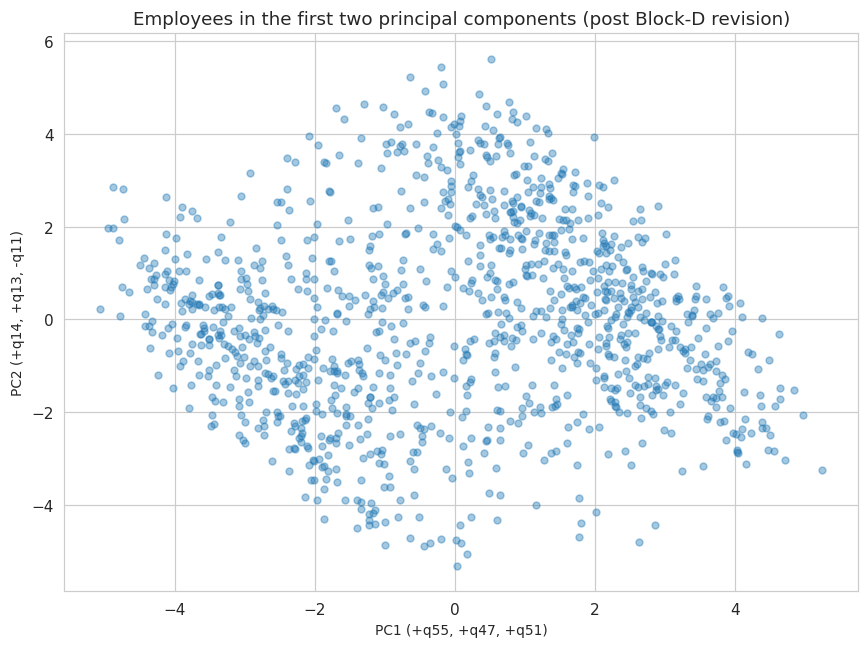

In [18]:
# Cell 10 — 2-D scatter of the first two principal components
def top_loading_label(pc_name, loadings_df, n=3):
    top = loadings_df[pc_name].abs().sort_values(ascending=False).head(n)
    parts = []
    for var in top.index:
        sign = '+' if loadings_df.loc[var, pc_name] > 0 else '-'
        parts.append(f"{sign}{var}")
    return ", ".join(parts)

# Loadings for the FINAL (9-component, post-Block-D) PCA
loadings_final = pd.DataFrame(
    pca_final.components_.T,
    index=X_cat.columns,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS_FINAL)]
)

pc1_label = top_loading_label('PC1', loadings_final)
pc2_label = top_loading_label('PC2', loadings_final)

print(f"PC1 top loadings: {pc1_label}")
print(f"PC2 top loadings: {pc2_label}")

codes_of_interest = ['q55', 'q47', 'q51', 'q14', 'q13', 'q11']
print(mapping[mapping['short_id'].isin(codes_of_interest)])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca_df['PC1'], X_pca_df['PC2'], alpha=0.4, s=20)

# Dynamically set axis labels using the calculated top loadings
ax.set_xlabel(f'PC1 ({pc1_label})', fontsize=9)
ax.set_ylabel(f'PC2 ({pc2_label})', fontsize=9)

ax.set_title('Employees in the first two principal components (post Block-D revision)')
plt.tight_layout()
plt.savefig(FIGDIR / 'pca_2d_scatter.png', bbox_inches='tight')
plt.show()